In [1]:
# ============================================
# NOTEBOOK 04 - OPTIMIZACION DE HIPERPARAMETROS
# Evaluacion Parcial N°2 - SCY1101
# ============================================
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from data_preprocessing import dividir_datos
from model_training import entrenar_modelos_clasificacion, guardar_modelo
from model_evaluation import evaluar_clasificacion
from hyperparameter_tuning import (
    grid_search_random_forest,
    randomized_search_gradient_boosting,
    comparar_antes_despues_tuning,
    graficar_impacto_hiperparametros,
)

sns.set_theme(style="whitegrid")
print("Librerias cargadas correctamente")

Librerias cargadas correctamente


In [2]:
# ============================================
# CARGA Y PREPARACION DE DATOS
# ============================================
consultas = pd.read_parquet("../data/02_intermediate/consultas_cleaned.parquet")
pacientes = pd.read_parquet("../data/02_intermediate/pacientes_cleaned.parquet")
examenes = pd.read_parquet("../data/02_intermediate/examenes_cleaned.parquet")
medicamentos = pd.read_parquet("../data/02_intermediate/medicamentos_cleaned.parquet")

df = consultas.merge(pacientes, on="id_paciente", how="left")
df = df.merge(examenes, on="id_consulta", how="left")
df = df.merge(medicamentos, on="id_consulta", how="left")

feature_cols = [
    'id_medico', 'resultado', 'duracion_dias', 'costo_unitario',
    'id_examen', 'id_prescripcion'
]

mediana_costo = df['costo'].median()
df['costo_alto'] = (df['costo'] > mediana_costo).astype(int)

X = df[feature_cols].fillna(0)
y = df['costo_alto']

X_train, X_test, y_train, y_test = dividir_datos(X, y)

# Entrenar modelos base para comparar despues
modelos_base = entrenar_modelos_clasificacion(X_train, y_train)

print("\nDatos preparados correctamente")

 Train: 936 filas | Test: 234 filas
Entrenando Logistic Regression...
  Logistic Regression entrenado correctamente
Entrenando Decision Tree...
  Decision Tree entrenado correctamente
Entrenando Random Forest...
  Random Forest entrenado correctamente
Entrenando Gradient Boosting...
  Gradient Boosting entrenado correctamente
Entrenando KNN...
  KNN entrenado correctamente
Entrenando SVM...
  SVM entrenado correctamente
Entrenando Naive Bayes...
  Naive Bayes entrenado correctamente

Datos preparados correctamente


In [3]:
# ============================================
# GRIDSEARCHCV - RANDOM FOREST
# ============================================
print("Iniciando GridSearchCV para Random Forest...")
print("Esto puede tardar unos minutos...")
print("="*55)

resultados_grid = grid_search_random_forest(X_train, y_train, cv=5)

print(f"\nMejores parametros encontrados:")
for param, valor in resultados_grid['mejores_params'].items():
    print(f"  {param}: {valor}")
print(f"\nMejor F1 CV: {resultados_grid['mejor_score']:.4f}")

Iniciando GridSearchCV para Random Forest...
Esto puede tardar unos minutos...
Ejecutando GridSearchCV para Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Mejores parametros: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Mejor F1 CV: 0.5807

Mejores parametros encontrados:
  model__max_depth: None
  model__min_samples_leaf: 2
  model__min_samples_split: 2
  model__n_estimators: 200

Mejor F1 CV: 0.5807


In [4]:
# ============================================
# RANDOMIZEDSEARCHCV - GRADIENT BOOSTING
# ============================================
print("Iniciando RandomizedSearchCV para Gradient Boosting...")
print("Esto puede tardar unos minutos...")
print("="*55)

resultados_random = randomized_search_gradient_boosting(X_train, y_train, cv=5, n_iter=20)

print(f"\nMejores parametros encontrados:")
for param, valor in resultados_random['mejores_params'].items():
    print(f"  {param}: {valor}")
print(f"\nMejor F1 CV: {resultados_random['mejor_score']:.4f}")

Iniciando RandomizedSearchCV para Gradient Boosting...
Esto puede tardar unos minutos...
Ejecutando RandomizedSearchCV para Gradient Boosting...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores parametros: {'model__subsample': 0.8, 'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__max_depth': 4, 'model__learning_rate': 0.1}
Mejor F1 CV: 0.5923

Mejores parametros encontrados:
  model__subsample: 0.8
  model__n_estimators: 300
  model__min_samples_split: 5
  model__max_depth: 4
  model__learning_rate: 0.1

Mejor F1 CV: 0.5923


In [5]:
# ============================================
# COMPARACION ANTES Y DESPUES DEL TUNING
# ============================================
print("Comparacion Random Forest:")
comp_rf = comparar_antes_despues_tuning(
    modelos_base["Random Forest"],
    resultados_grid["mejor_modelo"],
    X_test, y_test,
    "Random Forest"
)

print("\nComparacion Gradient Boosting:")
comp_gb = comparar_antes_despues_tuning(
    modelos_base["Gradient Boosting"],
    resultados_random["mejor_modelo"],
    X_test, y_test,
    "Gradient Boosting"
)

Comparacion Random Forest:

Comparacion antes/despues de tuning - Random Forest:
      version  accuracy  f1_score
0        Base    0.6282    0.6271
1  Optimizado    0.6538    0.6537

Comparacion Gradient Boosting:

Comparacion antes/despues de tuning - Gradient Boosting:
      version  accuracy  f1_score
0        Base    0.6239    0.6225
1  Optimizado    0.6282    0.6287


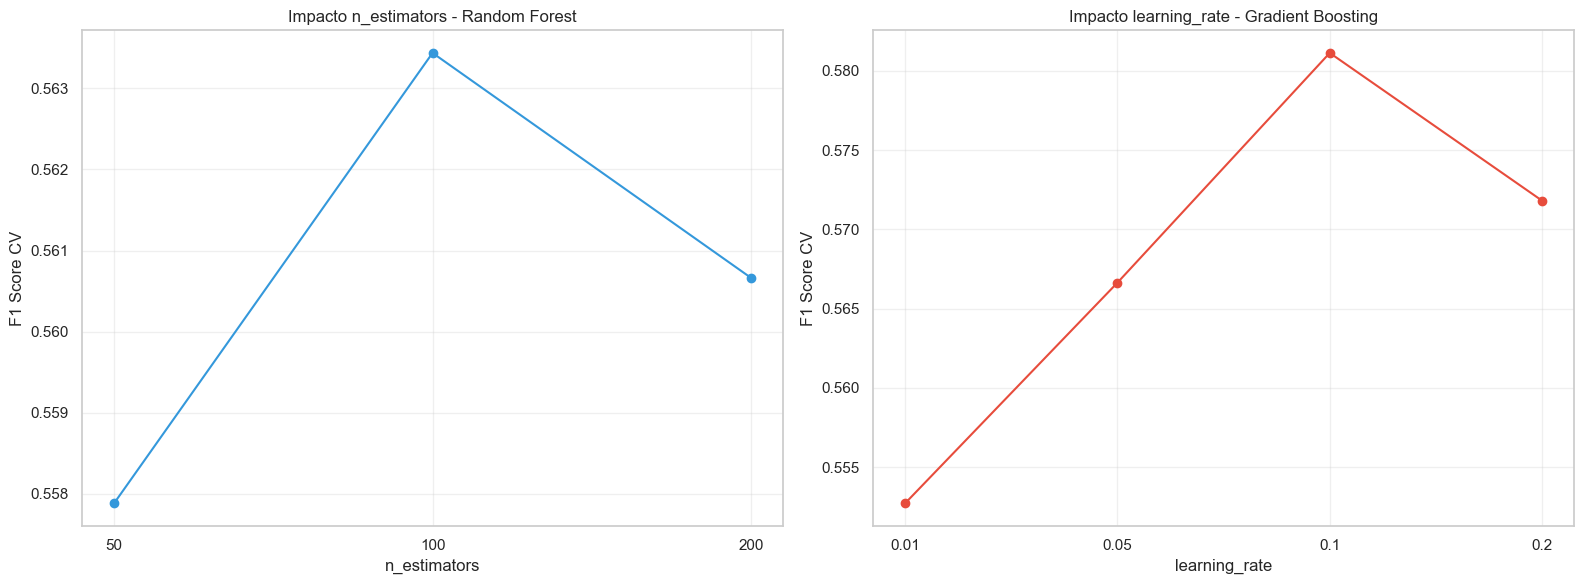

Grafico guardado


In [6]:
# ============================================
# VISUALIZACION IMPACTO HIPERPARAMETROS
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Impacto n_estimators en Random Forest
df_grid = resultados_grid["resultados_cv"]
n_est = df_grid.groupby("param_model__n_estimators")["mean_test_score"].mean()
axes[0].plot(n_est.index.astype(str), n_est.values, marker="o", color="#3498db")
axes[0].set_title("Impacto n_estimators - Random Forest")
axes[0].set_xlabel("n_estimators")
axes[0].set_ylabel("F1 Score CV")
axes[0].grid(True, alpha=0.3)

# Impacto learning_rate en Gradient Boosting
df_random = resultados_random["resultados_cv"]
lr = df_random.groupby("param_model__learning_rate")["mean_test_score"].mean()
axes[1].plot(lr.index.astype(str), lr.values, marker="o", color="#e74c3c")
axes[1].set_title("Impacto learning_rate - Gradient Boosting")
axes[1].set_xlabel("learning_rate")
axes[1].set_ylabel("F1 Score CV")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../src/results/plots/04_impacto_hiperparametros.png", dpi=150)
plt.show()
print("Grafico guardado")

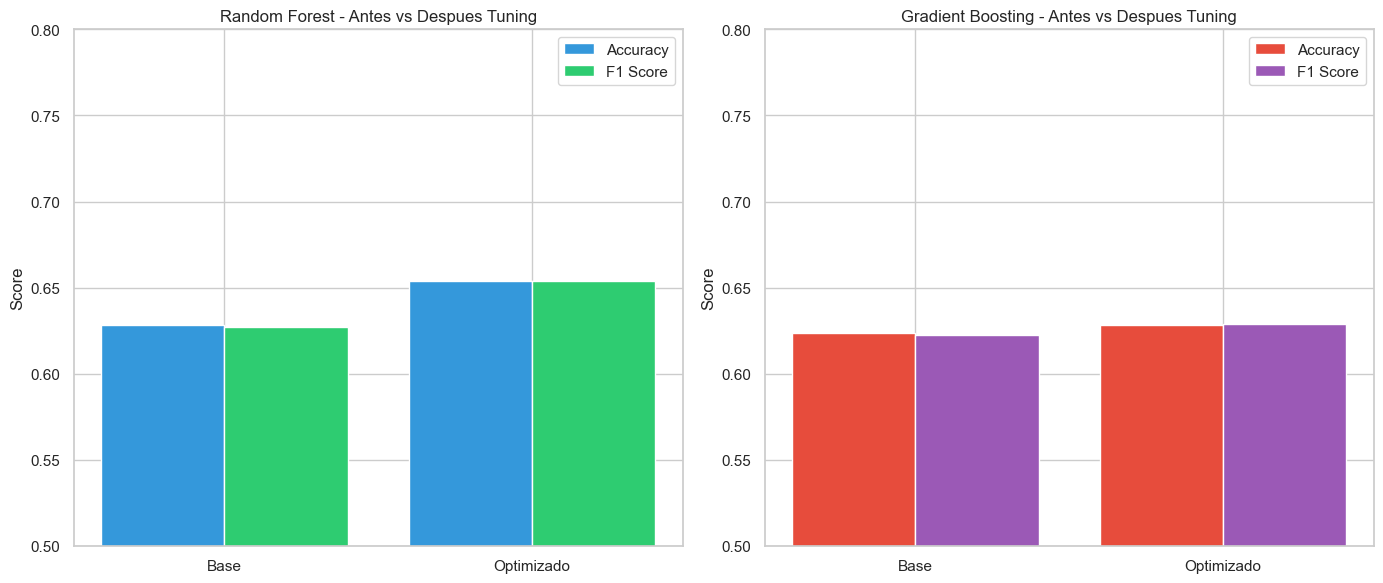

Grafico guardado


In [7]:
# ============================================
# VISUALIZACION COMPARACION ANTES/DESPUES
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest
categorias = ['Base', 'Optimizado']
accuracy_rf = [comp_rf['accuracy'].values[0], comp_rf['accuracy'].values[1]]
f1_rf = [comp_rf['f1_score'].values[0], comp_rf['f1_score'].values[1]]

x = np.arange(len(categorias))
axes[0].bar(x - 0.2, accuracy_rf, 0.4, label='Accuracy', color='#3498db')
axes[0].bar(x + 0.2, f1_rf, 0.4, label='F1 Score', color='#2ecc71')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categorias)
axes[0].set_title("Random Forest - Antes vs Despues Tuning")
axes[0].set_ylabel("Score")
axes[0].legend()
axes[0].set_ylim(0.5, 0.8)

# Gradient Boosting
accuracy_gb = [comp_gb['accuracy'].values[0], comp_gb['accuracy'].values[1]]
f1_gb = [comp_gb['f1_score'].values[0], comp_gb['f1_score'].values[1]]

axes[1].bar(x - 0.2, accuracy_gb, 0.4, label='Accuracy', color='#e74c3c')
axes[1].bar(x + 0.2, f1_gb, 0.4, label='F1 Score', color='#9b59b6')
axes[1].set_xticks(x)
axes[1].set_xticklabels(categorias)
axes[1].set_title("Gradient Boosting - Antes vs Despues Tuning")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].set_ylim(0.5, 0.8)

plt.tight_layout()
plt.savefig("../src/results/plots/04_antes_despues_tuning.png", dpi=150)
plt.show()
print("Grafico guardado")

In [8]:
# ============================================
# GUARDAR MODELOS OPTIMIZADOS
# ============================================
guardar_modelo(
    resultados_grid["mejor_modelo"],
    "../src/models/trained_models/random_forest_optimizado.joblib"
)

guardar_modelo(
    resultados_random["mejor_modelo"],
    "../src/models/trained_models/gradient_boosting_optimizado.joblib"
)

# Guardar resultados
resumen_tuning = pd.DataFrame({
    "modelo": ["Random Forest", "Gradient Boosting"],
    "f1_base": [comp_rf['f1_score'].values[0], comp_gb['f1_score'].values[0]],
    "f1_optimizado": [comp_rf['f1_score'].values[1], comp_gb['f1_score'].values[1]],
    "mejora": [
        comp_rf['f1_score'].values[1] - comp_rf['f1_score'].values[0],
        comp_gb['f1_score'].values[1] - comp_gb['f1_score'].values[0],
    ],
    "mejor_score_cv": [
        resultados_grid["mejor_score"],
        resultados_random["mejor_score"],
    ],
})

resumen_tuning.to_csv("../src/results/metrics/resumen_tuning.csv", index=False)

print("Modelos optimizados guardados")
print("\nResumen del proceso de optimizacion:")
print(resumen_tuning.to_string())

Modelo guardado en: ../src/models/trained_models/random_forest_optimizado.joblib
Modelo guardado en: ../src/models/trained_models/gradient_boosting_optimizado.joblib
Modelos optimizados guardados

Resumen del proceso de optimizacion:
              modelo  f1_base  f1_optimizado  mejora  mejor_score_cv
0      Random Forest   0.6271         0.6537  0.0266        0.580724
1  Gradient Boosting   0.6225         0.6287  0.0062        0.592281


In [1]:
# ============================================
# RESUMEN NOTEBOOK 04 - OPTIMIZACION
# ============================================
print("""
RESUMEN DE ESTE NOTEBOOK
========================

Este notebook aplico dos tecnicas de optimizacion de hiperparametros
para mejorar el rendimiento y corregir el overfitting detectado.

1. GRIDSEARCHCV - RANDOM FOREST
   Busqueda exhaustiva sobre todas las combinaciones posibles.
   - Hiperparametros probados: 4
   - Combinaciones totales:   108
   - Folds de validacion:     5
   - Total de entrenamientos: 540

   Espacio de busqueda:
   - n_estimators:      [50, 100, 200]
   - max_depth:         [3, 5, 10, None]
   - min_samples_split: [2, 5, 10]
   - min_samples_leaf:  [1, 2, 4]

   Mejores hiperparametros:
   - n_estimators:      200
   - max_depth:         None
   - min_samples_split: 2
   - min_samples_leaf:  2  (clave para reducir overfitting)
   - Mejor F1 CV:       0.5807

   Se eligio GridSearchCV porque Random Forest tenia overfitting severo
   y necesitabamos una busqueda exhaustiva y sistematica.

2. RANDOMIZEDSEARCHCV - GRADIENT BOOSTING
   Busqueda aleatoria sobre un subconjunto de combinaciones.
   - Iteraciones aleatorias: 20
   - Folds de validacion:    5
   - Total de entrenamientos: 100

   Espacio de busqueda:
   - n_estimators:      [50, 100, 200, 300]
   - max_depth:         [3, 4, 5, 6]
   - learning_rate:     [0.01, 0.05, 0.1, 0.2]
   - subsample:         [0.6, 0.8, 1.0]
   - min_samples_split: [2, 5, 10]

   Mejores hiperparametros:
   - n_estimators:      300
   - max_depth:         4
   - learning_rate:     0.1
   - subsample:         0.8
   - min_samples_split: 5
   - Mejor F1 CV:       0.5923

   Se eligio RandomizedSearchCV porque el espacio de busqueda era mayor
   y una busqueda aleatoria es mas eficiente computacionalmente.

3. IMPACTO DEL TUNING
   Modelo              F1 Base   F1 Optimizado   Mejora
   Random Forest       0.6271    0.6537          +4.2%
   Gradient Boosting   0.6225    0.6287          +1.0%

4. MODELOS GUARDADOS
   - random_forest_optimizado.joblib
   - gradient_boosting_optimizado.joblib
   - src/results/metrics/resumen_tuning.csv

CONCLUSION:
GridSearchCV mejoro Random Forest en +4.2% reduciendo el overfitting
gracias al parametro min_samples_leaf=2. RandomizedSearchCV mejoro
Gradient Boosting en +1.0%. El modelo final ganador es Random Forest
Optimizado con F1=0.6537.
""")


RESUMEN DE ESTE NOTEBOOK

Este notebook aplico dos tecnicas de optimizacion de hiperparametros
para mejorar el rendimiento y corregir el overfitting detectado.

1. GRIDSEARCHCV - RANDOM FOREST
   Busqueda exhaustiva sobre todas las combinaciones posibles.
   - Hiperparametros probados: 4
   - Combinaciones totales:   108
   - Folds de validacion:     5
   - Total de entrenamientos: 540

   Espacio de busqueda:
   - n_estimators:      [50, 100, 200]
   - max_depth:         [3, 5, 10, None]
   - min_samples_split: [2, 5, 10]
   - min_samples_leaf:  [1, 2, 4]

   Mejores hiperparametros:
   - n_estimators:      200
   - max_depth:         None
   - min_samples_split: 2
   - min_samples_leaf:  2  (clave para reducir overfitting)
   - Mejor F1 CV:       0.5807

   Se eligio GridSearchCV porque Random Forest tenia overfitting severo
   y necesitabamos una busqueda exhaustiva y sistematica.

2. RANDOMIZEDSEARCHCV - GRADIENT BOOSTING
   Busqueda aleatoria sobre un subconjunto de combinaciones